# TsPlots — 自定义绘图工具包

本 Notebook 演示 `TsPlots` 包的完整用法，包括：

1. **plot_series** — 时间序列折线图
2. **plot_scatter** — 散点图
3. **plot_acf / plot_pacf** — 自相关 / 偏自相关图
4. **样式定制** — 调色板、字体、图例、阴影、参考线

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Ts.TsPlots import plot_series, plot_scatter, plot_acf, plot_pacf
from Ts.TsPlots.style import DEFAULT_PALETTE, style_axes, apply_fonts

# 准备演示数据
np.random.seed(42)
t = np.arange(100)
df = pd.DataFrame({
    "GDP": np.cumsum(np.random.randn(100)) + 100,
    "Consumption": np.cumsum(np.random.randn(100) * 0.8) + 80,
    "Investment": np.cumsum(np.random.randn(100) * 1.5) + 30,
    "year": 1920 + t,
}).set_index("year")

print(df.head())

             GDP  Consumption  Investment
year                                     
1920  100.496714    78.867703   30.536681
1921  100.358450    78.531187   31.377858
1922  101.006138    78.257016   33.002435
1923  102.529168    77.615194   34.583138
1924  102.295015    77.486165   32.516634


---
## 1. plot_series — 时间序列折线图

多序列布局相关参数：

| 参数 | 默认值 | 含义 |
|---|---:|---|
| `facet` | `True` | 两条及以上序列按序列纵向分面；单序列仍返回一个坐标轴 |
| `sharex` | `True` | 分面之间统一 X 轴标度 |
| `sharey` | `False` | 分面之间统一 Y 轴标度 |
| `auto_dual_y` | `True` | `facet=False` 时自动把相近稳健尺度归为一组，并按组建立 Y 轴 |
| `scale_ratio_threshold` | `10.0` | 相邻尺度达到该比值时建立新的自动分组 |
| `axis_groups` | `None` | 手动指定 `{序列标签: 组标识}`；相同标识共用一个 Y 轴 |
| `max_y_axes` | `3` | Y 轴总数上限，包含左轴 |

返回对象：单序列或叠加图返回 `(fig, ax)`；分面图返回 `(fig, axes)`，其中 `axes` 是一维数组；多轴叠加图的第一个右轴通过 `ax.right_ax` 获取，全部右轴通过 `ax.extra_y_axes` 获取。

### 1.1 基础用法 — 单序列

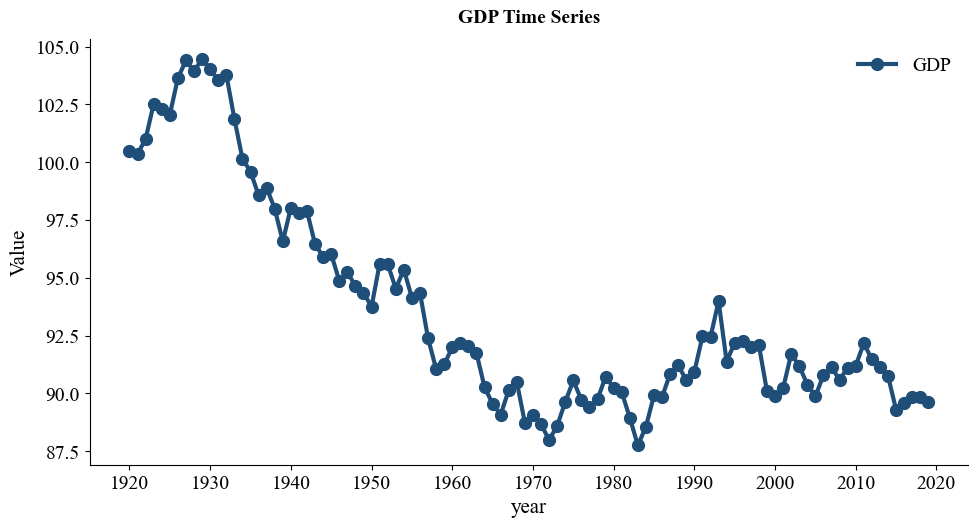

In [2]:
fig, ax = plot_series(df, y="GDP", title="GDP Time Series", ytitle="Value")
plt.show()

### 1.2 多序列默认分面（`facet=True`）

每条序列各占一个纵向面板。默认统一 X 轴标度（`sharex=True`），但各面板保留独立 Y 轴标度（`sharey=False`）。

<class 'numpy.ndarray'> (3,)
第一个分面标题： GDP
X 轴是否共享： True
Y 轴是否共享： False


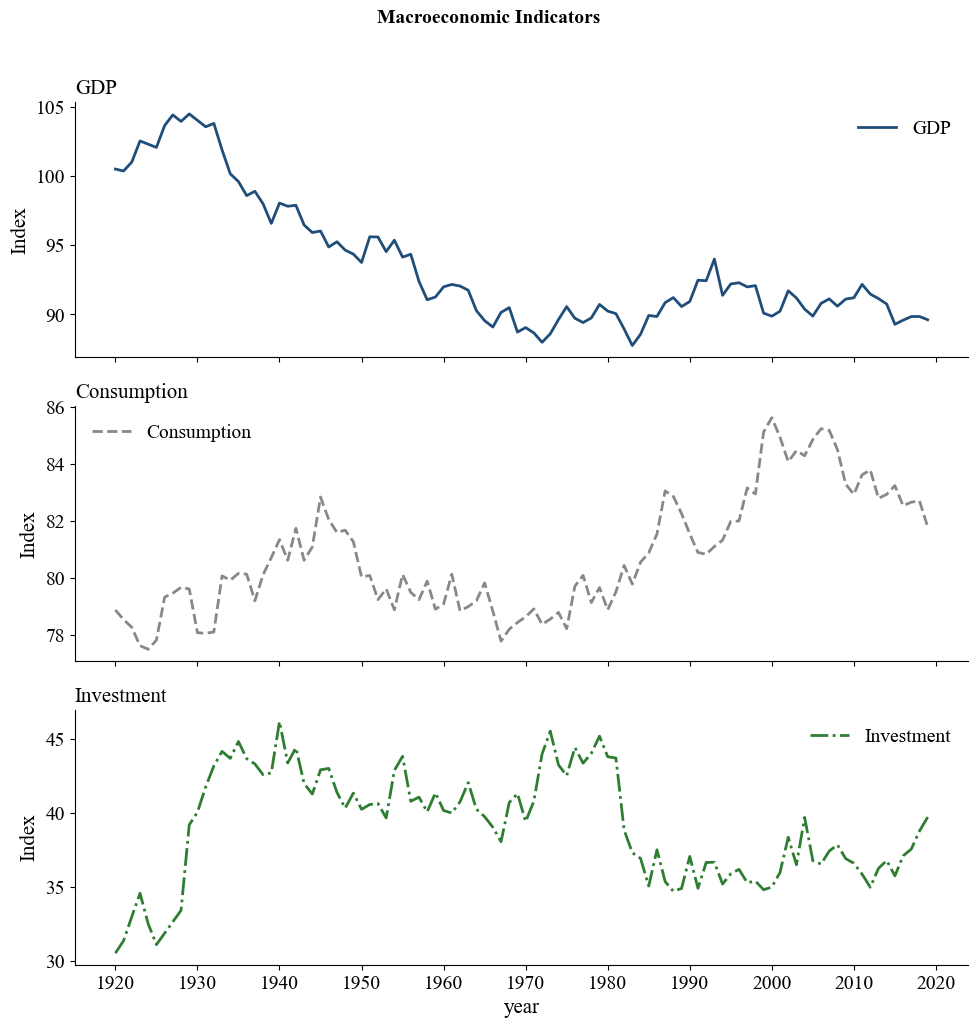

In [3]:
fig, axes = plot_series(
    df[["GDP", "Consumption", "Investment"]],
    title="Macroeconomic Indicators",
    ytitle="Index",
    markersize=0,
    linewidth=2,
)
print(type(axes), axes.shape)
print("第一个分面标题：", axes[0].get_title(loc="left"))
print("X 轴是否共享：", axes[0].get_shared_x_axes().joined(axes[0], axes[1]))
print("Y 轴是否共享：", axes[0].get_shared_y_axes().joined(axes[0], axes[1]))
plt.show()

### 1.3 分别设置 X/Y 轴是否统一标度

下面关闭 X 轴共享、开启 Y 轴共享。`axes[0]` 和 `axes[1]` 分别是两个分面的坐标轴对象。

X 轴是否共享： False
Y 轴是否共享： True


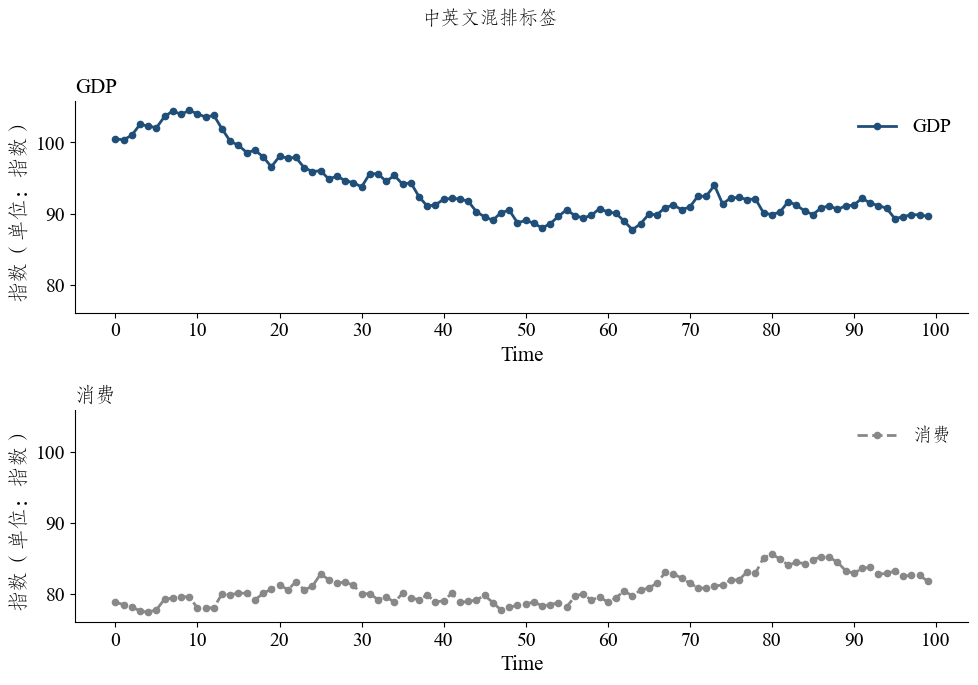

In [4]:
data_dict = {"GDP": df["GDP"].values, "消费": df["Consumption"].values}
fig, axes = plot_series(
    data_dict,
    x=t,
    sharex=False,
    sharey=True,
    title="中英文混排标签",
    ytitle="指数",
    linewidth=2,
    markersize=3,
    unit="指数",
)
print("X 轴是否共享：", axes[0].get_shared_x_axes().joined(axes[0], axes[1]))
print("Y 轴是否共享：", axes[0].get_shared_y_axes().joined(axes[0], axes[1]))
plt.show()

### 1.4 关闭分面后自动建立多个 Y 轴

设置 `facet=False` 后，多序列叠加显示。函数按稳健尺度排序，把相邻尺度比小于 `scale_ratio_threshold` 的序列归为一组；不同组使用不同 Y 轴。`max_y_axes` 默认限制为 3 个总轴。

图中坐标轴数量： 3
第 1 个轴： ['增长率（%）']
第 2 个轴： ['GDP（亿元）']
第 3 个轴： ['人口（人）']
第一个右轴是否可直接访问： True


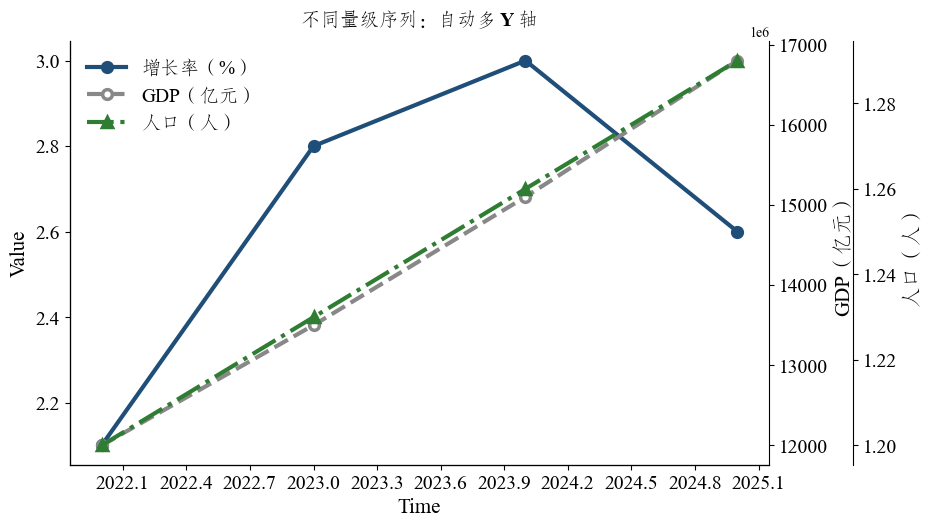

In [5]:
scale_data = {
    "增长率（%）": [2.1, 2.8, 3.0, 2.6],
    "GDP（亿元）": [12000, 13500, 15100, 16800],
    "人口（人）": [1_200_000, 1_230_000, 1_260_000, 1_290_000],
}
fig, ax = plot_series(
    scale_data,
    x=[2022, 2023, 2024, 2025],
    facet=False,
    title="不同量级序列：自动多 Y 轴",
)
all_y_axes = [ax, *ax.extra_y_axes]
print("图中坐标轴数量：", len(fig.axes))
for index, y_axis in enumerate(all_y_axes):
    print(f"第 {index + 1} 个轴：", [line.get_label() for line in y_axis.lines])
print("第一个右轴是否可直接访问：", ax.right_ax is ax.extra_y_axes[0])
plt.show()

### 1.5 用户指定轴分组

`axis_groups` 的键必须与绘制标签完全一致。相同组标识的序列共用一个 Y 轴；手动分组优先于自动判断。第一条序列所在组固定使用左轴。

第 1 个轴： ['GDP（亿元）', '财政收入（亿元）']
第 2 个轴： ['增长率（%）']
第 3 个轴： ['人口（人）']


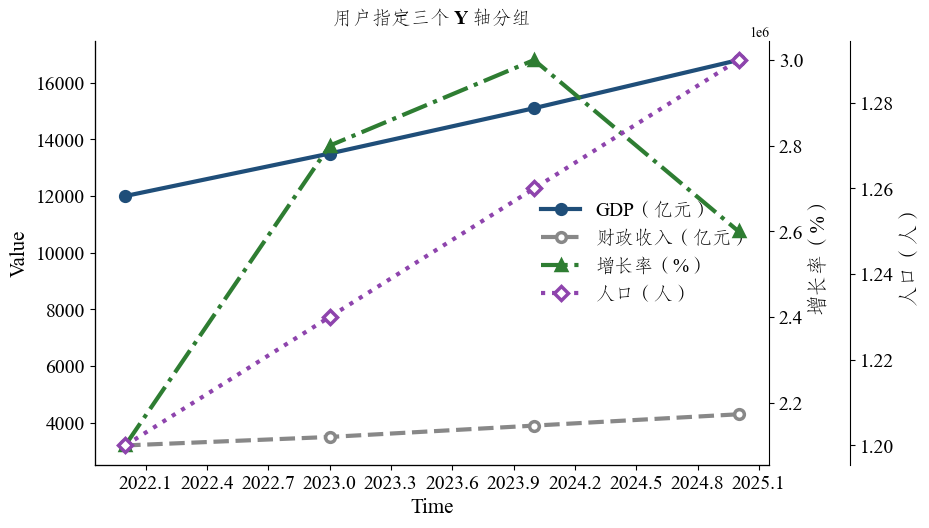

In [6]:
manual_data = {
    "GDP（亿元）": [12000, 13500, 15100, 16800],
    "财政收入（亿元）": [3200, 3500, 3900, 4300],
    "增长率（%）": [2.1, 2.8, 3.0, 2.6],
    "人口（人）": [1_200_000, 1_230_000, 1_260_000, 1_290_000],
}
manual_groups = {
    "GDP（亿元）": "经济总量",
    "财政收入（亿元）": "经济总量",
    "增长率（%）": "比率",
    "人口（人）": "人口规模",
}
fig, ax = plot_series(
    manual_data,
    x=[2022, 2023, 2024, 2025],
    facet=False,
    axis_groups=manual_groups,
    max_y_axes=3,
    title="用户指定三个 Y 轴分组",
)
for index, y_axis in enumerate([ax, *ax.extra_y_axes]):
    print(f"第 {index + 1} 个轴：", [line.get_label() for line in y_axis.lines])
plt.show()

### 1.6 禁用自动多 Y 轴

未提供 `axis_groups` 时，`auto_dual_y=False` 会强制所有序列使用同一个 Y 轴。该参数保留原名称以兼容现有代码。

图中坐标轴数量： 1
同一轴上的序列： ['增长率（%）', 'GDP（亿元）', '人口（人）']
右轴列表： []


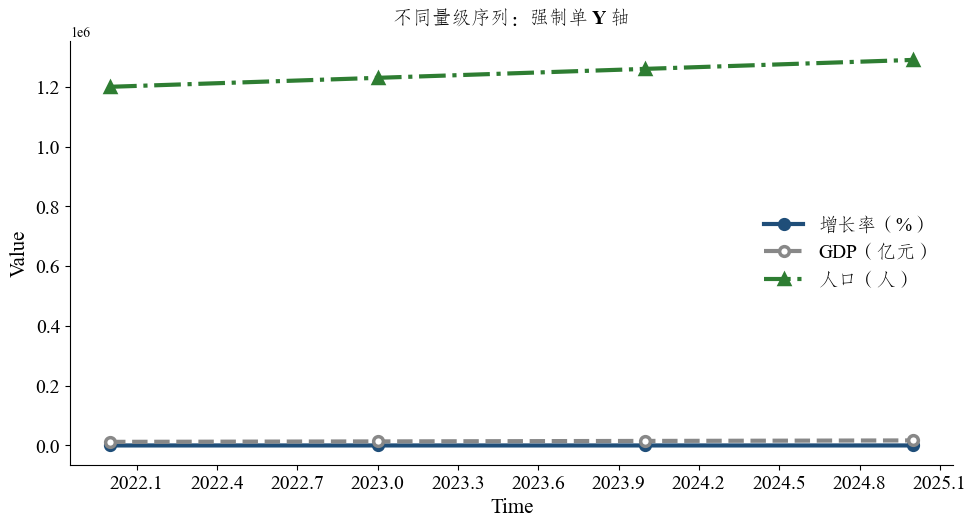

In [7]:
fig, ax = plot_series(
    scale_data,
    x=[2022, 2023, 2024, 2025],
    facet=False,
    auto_dual_y=False,
    title="不同量级序列：强制单 Y 轴",
)
print("图中坐标轴数量：", len(fig.axes))
print("同一轴上的序列：", [line.get_label() for line in ax.lines])
print("右轴列表：", ax.extra_y_axes)
plt.show()

### 1.7 阴影区间 (`shade`)

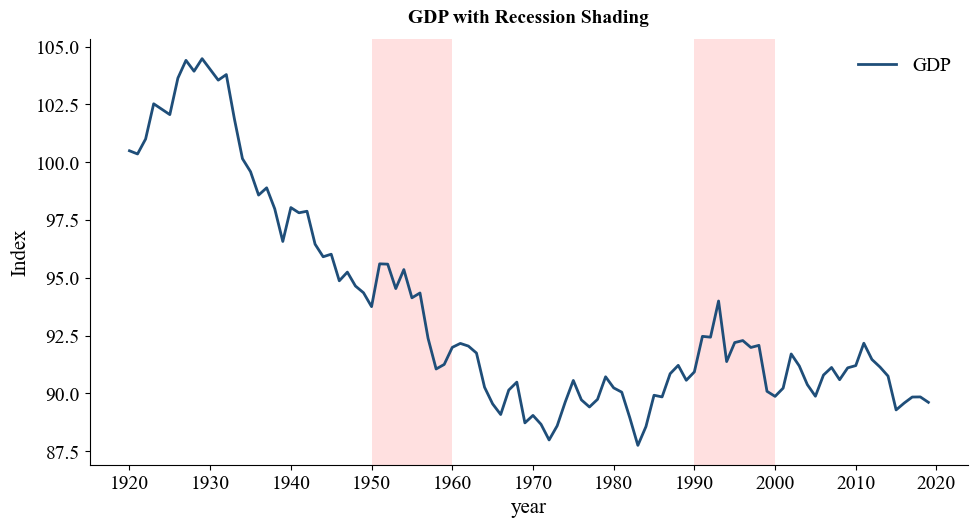

In [8]:
fig, ax = plot_series(
    df["GDP"],
    title="GDP with Recession Shading",
    ytitle="Index",
    markersize=0, linewidth=2,
    shade=[(1950, 1960), (1990, 2000)],  # 与 DataFrame 年份索引一致
    shade_color="#ff9999", shade_alpha=0.3,
)
plt.show()

### 1.8 竖线标注 (`vlines`)

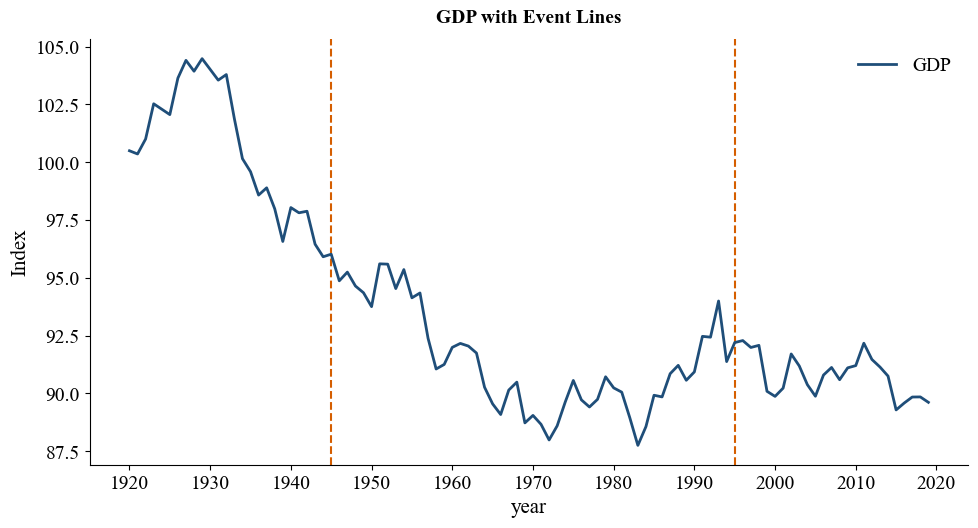

In [9]:
fig, ax = plot_series(
    df["GDP"],
    title="GDP with Event Lines",
    ytitle="Index",
    markersize=0, linewidth=2,
    vlines=[1945, 1995],
    vline_color="#D55E00", vline_linestyle="--",
)
plt.show()

### 1.9 数值标注 (`show_values`)

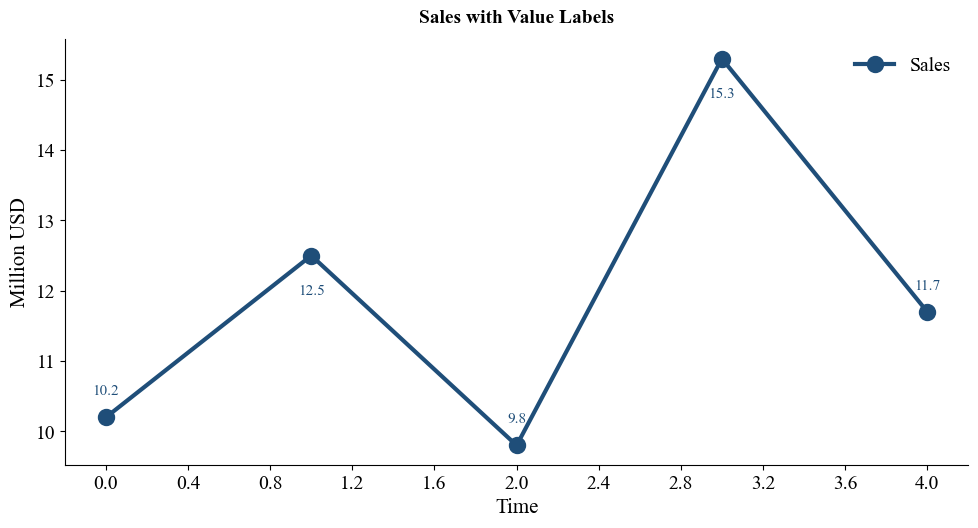

In [10]:
short_series = pd.Series([10.2, 12.5, 9.8, 15.3, 11.7], name="Sales")
fig, ax = plot_series(
    short_series,
    title="Sales with Value Labels",
    ytitle="Million USD",
    show_values=True, value_decimals=1,
    markersize=10,
)
plt.show()

### 1.10 网格 + 自定义颜色 + 底部标题

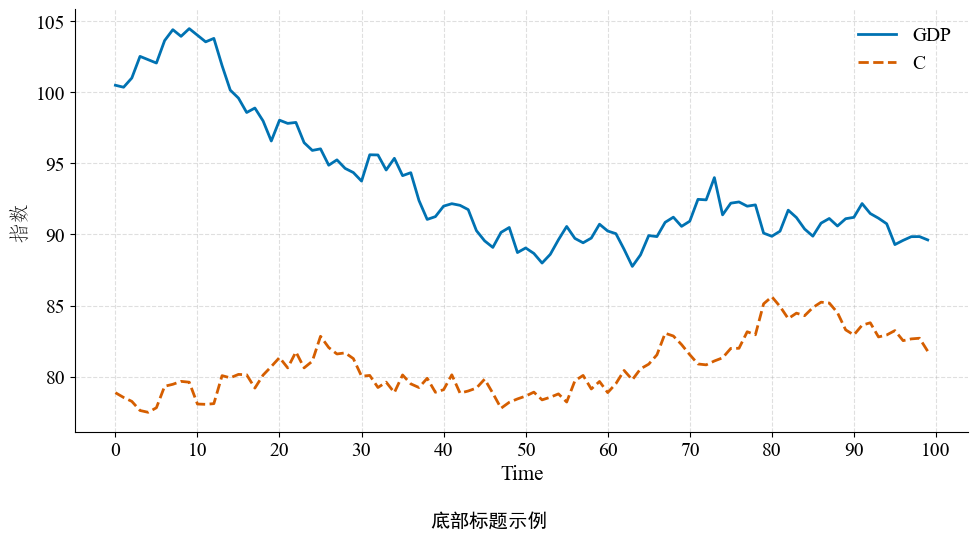

In [11]:
fig, ax = plot_series(
    {"GDP": df["GDP"], "C": df["Consumption"]},
    facet=False,
    title="底部标题示例", title_position="bottom",
    ytitle="指数", grid=True,
    colors=["#0072B2", "#D55E00"],
    markersize=0, linewidth=2,
)
plt.show()

---
## 2. plot_scatter — 散点图

### 2.1 基础散点 — DataFrame 列

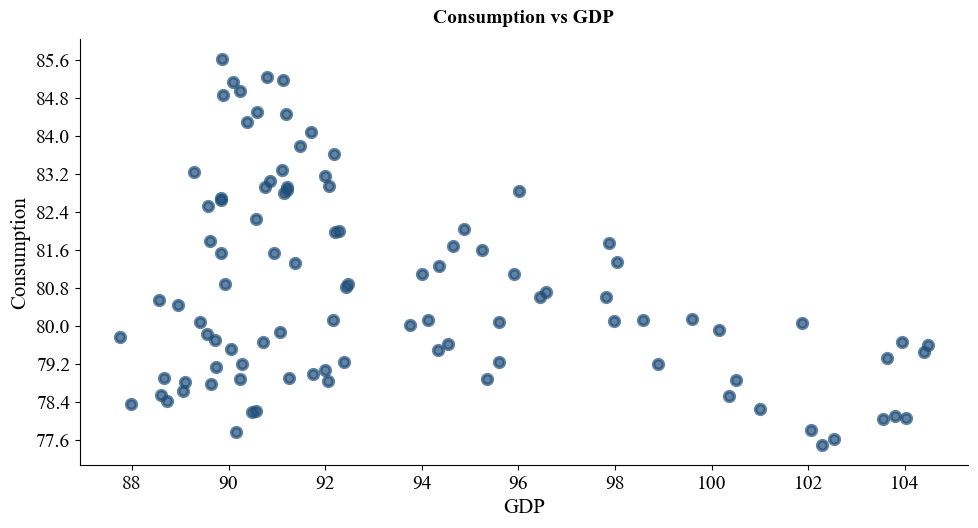

In [12]:
fig, ax = plot_scatter(
    df, x="GDP", y="Consumption",
    title="Consumption vs GDP",
    show_legend=False,
)
plt.show()

### 2.2 带 OLS 趋势线 (fit_line=True)

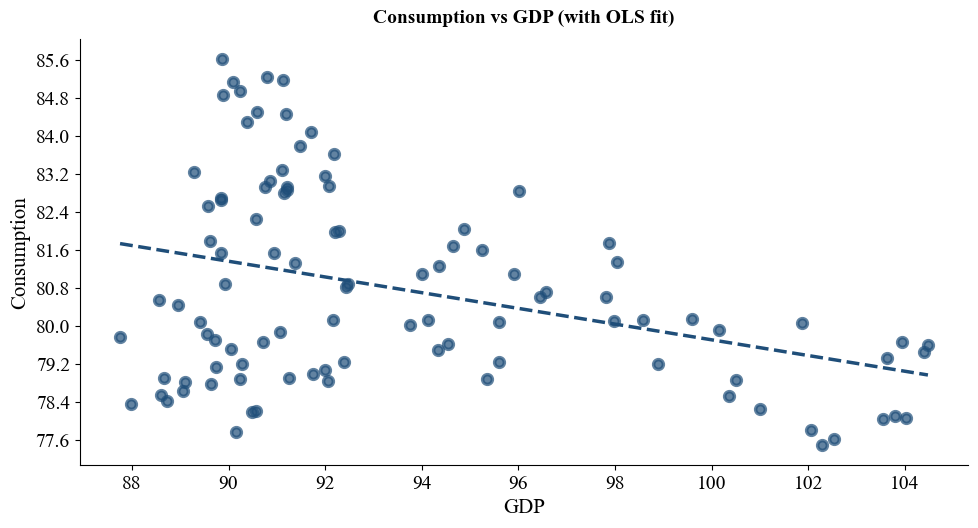

In [13]:
fig, ax = plot_scatter(
    df, x="GDP", y="Consumption",
    title="Consumption vs GDP (with OLS fit)",
    fit_line=True, fit_linewidth=2.5, fit_linestyle="--",
    show_legend=False,
)
plt.show()

### 2.3 分组散点 — group 参数

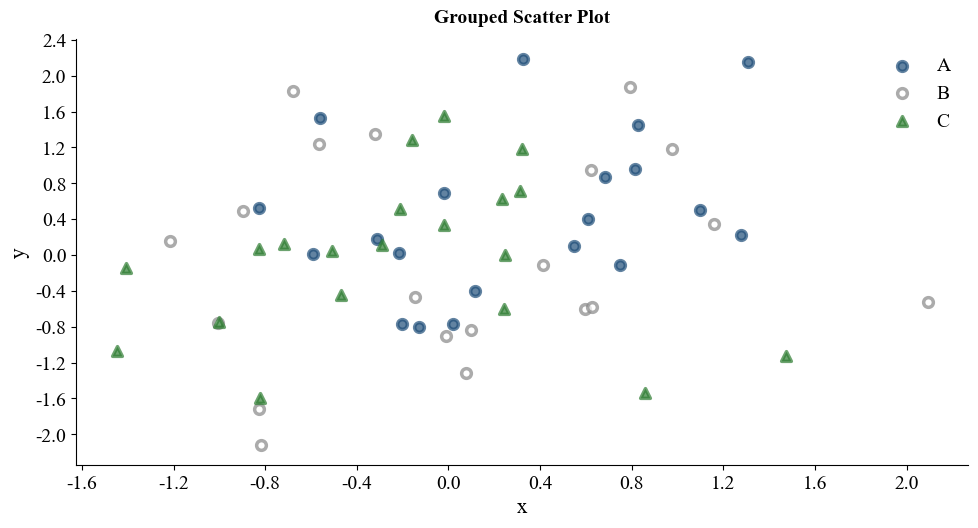

In [14]:
# 构造分组数据
group_df = pd.DataFrame({
    "x": np.random.randn(60),
    "y": np.random.randn(60),
    "category": ["A"] * 20 + ["B"] * 20 + ["C"] * 20,
})

fig, ax = plot_scatter(
    group_df, x="x", y="y", group="category",
    title="Grouped Scatter Plot",
)
plt.show()

### 2.4 竖线 / 横线 + 数值标注

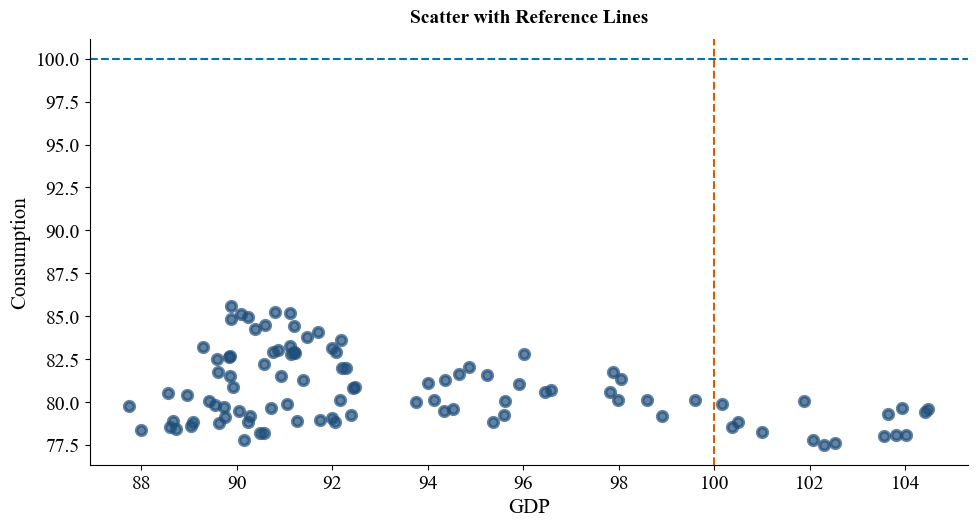

In [15]:
fig, ax = plot_scatter(
    df, x="GDP", y="Consumption",
    title="Scatter with Reference Lines",
    vlines=[100], hlines=[100],
    vline_color="#D55E00", hline_color="#0072B2",
    show_legend=False,
)
plt.show()

### 2.5 等比例坐标轴 (equal_aspect)

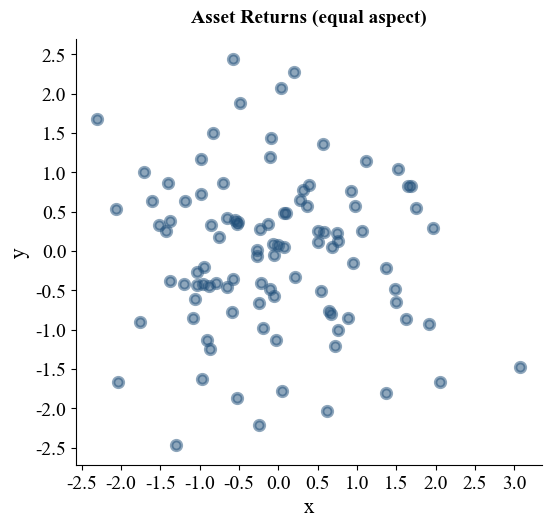

In [16]:
x_returns = np.random.randn(100)
y_returns = np.random.randn(100)
fig, ax = plot_scatter(
    x=x_returns, y=y_returns,
    title="Asset Returns (equal aspect)",
    equal_aspect=True, alpha=0.5, show_legend=False,
)
plt.show()


---
## 3. plot_acf / plot_pacf — 自相关图

### 3.1 ACF 图 — AR(1) 过程

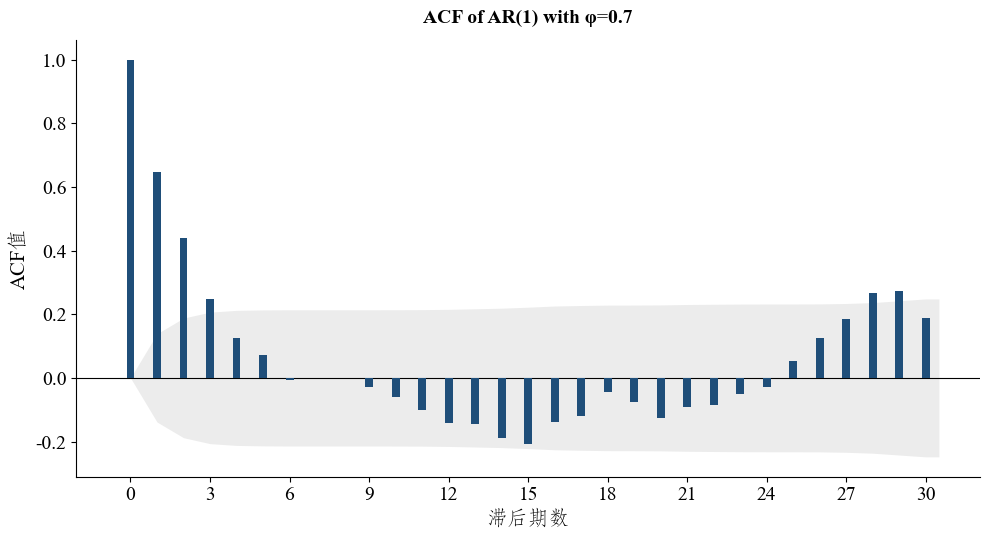

In [17]:
# 生成 AR(1) φ=0.7
from statsmodels.tsa.arima_process import ArmaProcess
ar = np.array([1, -0.7])
ma = np.array([1])
ar1_data = ArmaProcess(ar, ma).generate_sample(200)

fig, ax = plot_acf(ar1_data, nlags=30, title="ACF of AR(1) with φ=0.7")
plt.show()

### 3.2 PACF 图

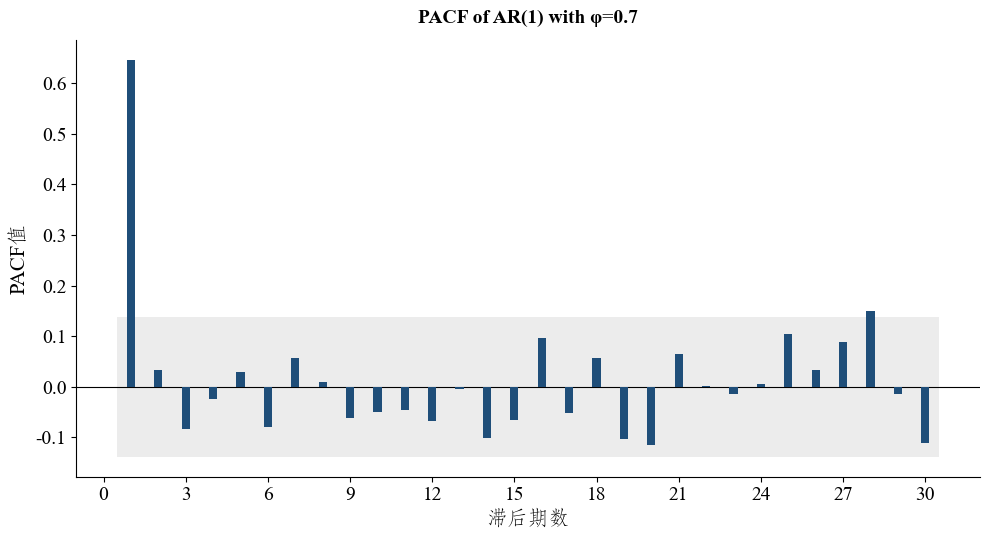

In [18]:
fig, ax = plot_pacf(ar1_data, nlags=30, title="PACF of AR(1) with φ=0.7")
plt.show()

### 3.3 ACF — 去掉 lag 0

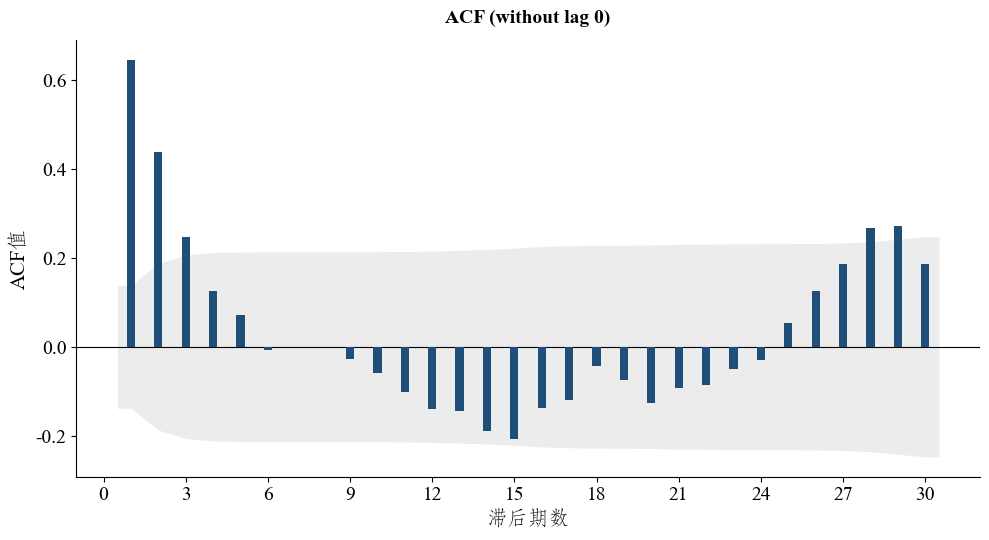

In [19]:
fig, ax = plot_acf(
    ar1_data, nlags=30, zero_lag=False,
    title="ACF (without lag 0)",
)
plt.show()

### 3.4 ACF — 99% 置信带

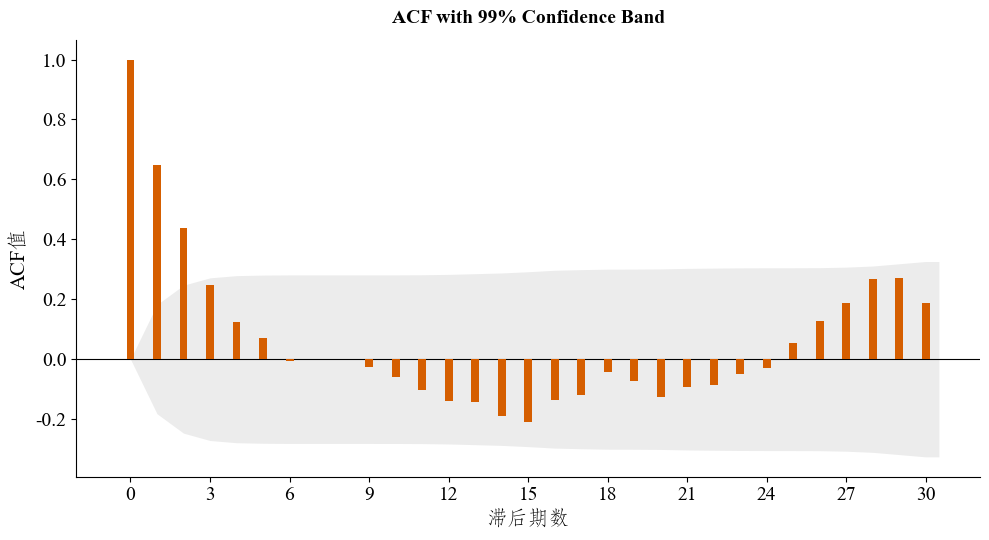

In [20]:
fig, ax = plot_acf(
    ar1_data, nlags=30, alpha=0.01,
    title="ACF with 99% Confidence Band",
    bar_color="#D55E00",
)
plt.show()

---
## 4. 样式系统

`TsPlots.style` 模块提供全局样式控制。

### 4.1 调色板 (Okabe-Ito 8色)

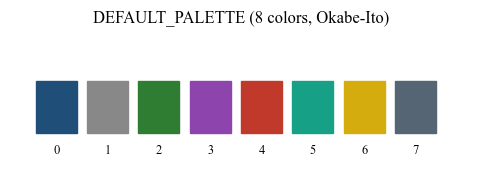

In [21]:
from Ts.TsPlots.style import DEFAULT_PALETTE

fig, ax = plt.subplots(figsize=(8, 2))
for i, color in enumerate(DEFAULT_PALETTE):
    ax.add_patch(plt.Rectangle((i, 0), 0.8, 1, color=color))
    ax.text(i + 0.4, -0.4, f"{i}", ha="center", fontsize=9)
ax.set_xlim(-0.5, len(DEFAULT_PALETTE) + 0.5)
ax.set_ylim(-1, 2)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"DEFAULT_PALETTE ({len(DEFAULT_PALETTE)} colors, Okabe-Ito)")
plt.show()

### 4.2 字体系统 — Times New Roman + 仿宋

Latin font: Times New Roman
CJK candidates: ['FangSong_GB2312', 'FZFangSong-Z02', 'FangSong']


C:\Users\NIU\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Times New Roman, FZFangSong-Z02.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\NIU\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) Times New Roman, FZFangSong-Z02.
  fig.canvas.print_figure(bytes_io, **kw)


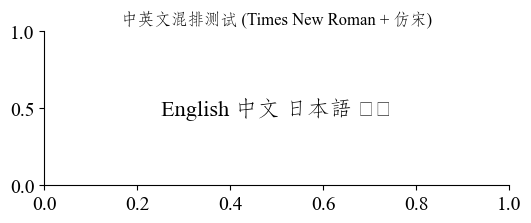

In [22]:
from Ts.TsPlots.style import apply_fonts, LATIN_FONT, CHINESE_FONT_CANDIDATES

print(f"Latin font: {LATIN_FONT}")
print(f"CJK candidates: {CHINESE_FONT_CANDIDATES}")

fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0.5, 0.5, "English 中文 日本語 한글", ha="center", va="center", fontsize=16, transform=ax.transAxes)
ax.set_title("中英文混排测试 (Times New Roman + 仿宋)")
style_axes(ax)
plt.show()

---
## 小结

| 函数 | 用途 | 关键参数 |
|------|------|----------|
| `plot_series()` | 时间序列折线图 | `data`, `x`, `y`, `facet`, `sharex`, `sharey`, `auto_dual_y`, `scale_ratio_threshold`, `axis_groups`, `max_y_axes` |
| `plot_scatter()` | 散点图 | `data`, `x`, `y`, `group`, `fit_line`, `hlines`, `vlines` |
| `plot_acf()` | 自相关图 | `data`, `nlags`, `alpha`, `zero_lag`, `bartlett_confint` |
| `plot_pacf()` | 偏自相关图 | `data`, `nlags`, `alpha` |

**样式常量** (from `TsPlots.style`)：
- `DEFAULT_PALETTE` — 8色调色板 (Okabe-Ito)
- `LATIN_FONT` / `CHINESE_FONT_CANDIDATES` — 字体配置
- `style_axes(ax)` — 统一坐标轴样式
- `apply_fonts()` — 应用字体配置